In [69]:
from scripts import s1_rvl, io
import matplotlib.pyplot as plt
import numpy as np
import os
from scripts.s1_io import (
    S1Annotation,
    find_safe_files,
    parse_annotation,
    read_slc_burst,
    slant_range_time_vector,
    _nearest_estimate,
)
%matplotlib widget

In [70]:
idx = 2

In [71]:
files = find_safe_files('data/S1_data/test2/S1A_IW_SLC__1SDV_20260205T165251_20260205T165321_063086_07EAEF_2642.SAFE', 'iw1', 'vv')
annot = parse_annotation(files['annotation'])

In [72]:
raw = read_slc_burst(files['measurement'], annot, idx)

In [73]:
deramped = s1_rvl.deramp_burst(raw, annot, idx)

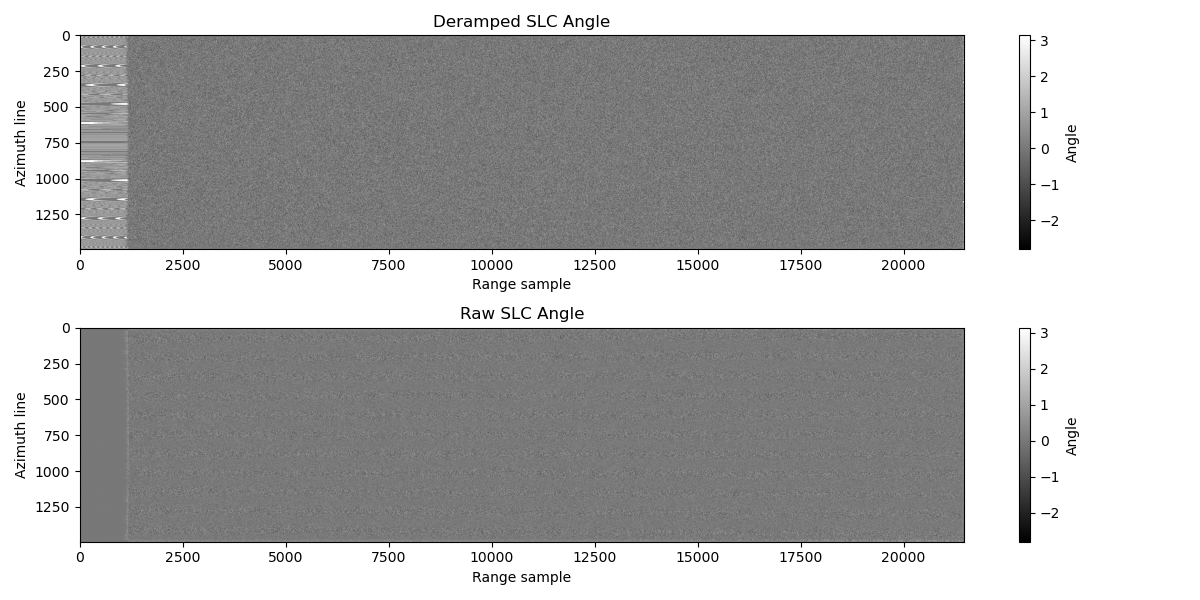

In [74]:
fig, ax = plt.subplots(2, 1,figsize=(12, 6))
img = ax[0].imshow(                                                                                                                                                                                                         
    np.angle(deramped),     
    cmap='gray',                                                                                                                                                                                                         
    aspect='auto',
    vmin=np.nanpercentile(np.angle(deramped), 5),                                                                                                                                                                                    
    vmax=np.nanpercentile(np.angle(deramped), 99),                                                                                                                                                                                   
    origin='upper',
)                                                                                                                                                                                                                        
plt.colorbar(img, ax=ax[0], label='Angle')
ax[0].set_xlabel('Range sample')                                                                                                                                                                                            
ax[0].set_ylabel('Azimuth line')
ax[0].set_title('Deramped SLC Angle')  

img1 = ax[1].imshow(                                                                                                                                                                                                         
    np.angle(raw),     
    cmap='gray',                                                                                                                                                                                                         
    aspect='auto',
    vmin=np.nanpercentile(np.angle(deramped), 5),                                                                                                                                                                                    
    vmax=np.nanpercentile(np.angle(deramped), 99),                                                                                                                                                                                   
    origin='upper',
)                                                                                                                                                                                                                        
plt.colorbar(img1, ax=ax[1], label='Angle')
ax[1].set_xlabel('Range sample')                                                                                                                                                                                            
ax[1].set_ylabel('Azimuth line')
ax[1].set_title('Raw SLC Angle') 


plt.tight_layout()                                                                                                                                                                                                       
plt.show()    

In [75]:
p0, p1, az_loc, rg_centers = s1_rvl.estimate_correlation_grid(
            deramped, 256, 512, 64, 128,
        )

In [81]:
f_dc, _, snr = s1_rvl.correlation_to_doppler(p0, p1, annot.prf, annot.wavelength)

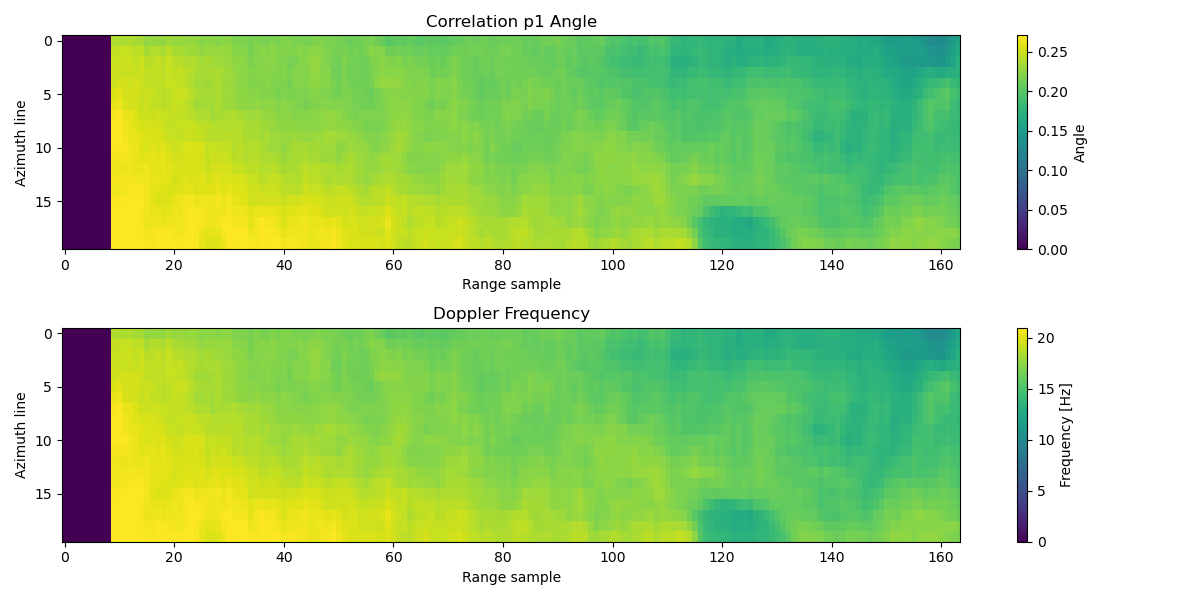

In [77]:
fig, ax = plt.subplots(2, 1,figsize=(12, 6))
img = ax[0].imshow(                                                                                                                                                                                                         
    np.angle(p1),     
    cmap='viridis',                                                                                                                                                                                                         
    aspect='auto',
    vmin=np.nanpercentile(np.angle(p1), 5),                                                                                                                                                                                    
    vmax=np.nanpercentile(np.angle(p1), 99),                                                                                                                                                                                   
    origin='upper',
)                                                                                                                                                                                                                        
plt.colorbar(img, ax=ax[0], label='Angle')
ax[0].set_xlabel('Range sample')                                                                                                                                                                                            
ax[0].set_ylabel('Azimuth line')
ax[0].set_title('Correlation p1 Angle')  

img1 = ax[1].imshow(                                                                                                                                                                                                         
    f_dc,     
    cmap='viridis',                                                                                                                                                                                                         
    aspect='auto',
    vmin=np.nanpercentile(f_dc, 5),                                                                                                                                                                                    
    vmax=np.nanpercentile(f_dc, 99),                                                                                                                                                                                   
    origin='upper',
)                                                                                                                                                                                                                        
plt.colorbar(img1, ax=ax[1], label='Frequency [Hz]')
ax[1].set_xlabel('Range sample')                                                                                                                                                                                            
ax[1].set_ylabel('Azimuth line')
ax[1].set_title('Doppler Frequency') 


plt.tight_layout()                                                                                                                                                                                                       
plt.show()    

In [78]:
f_geom = s1_rvl._geom_doppler_annotation(annot, idx, rg_centers).astype(np.float32)[np.newaxis, :]

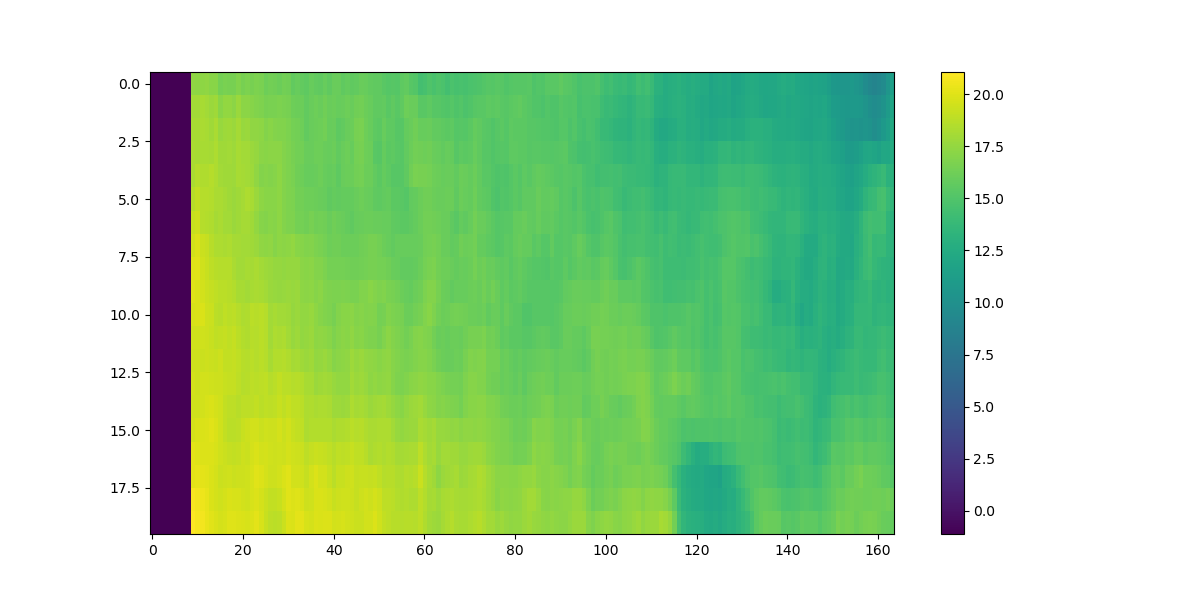

In [79]:
fig, ax = plt.subplots(figsize=(12, 6))
img = ax.imshow(f_dc-f_geom, aspect='auto', origin='upper')
plt.colorbar(img, ax=ax)
plt.show()
plt.savefig(f'plots/ocn_safe/doppler_estimation_{idx}.png', dpi=300)

In [80]:
burst_period_rows = annot.lines_per_burst / 64

In [82]:
f_dc = s1_rvl.descallop(f_dc, snr, burst_period_rows)

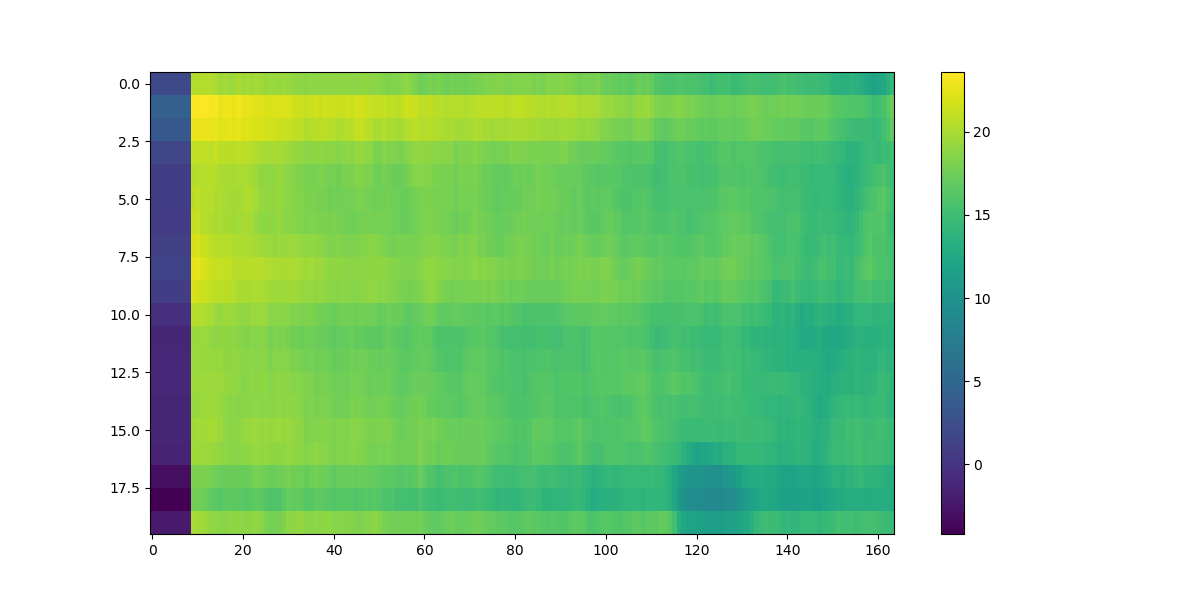

In [83]:
fig, ax = plt.subplots(figsize=(12, 6))
img = ax.imshow(f_dc, aspect='auto', origin='upper')
plt.colorbar(img, ax=ax)
plt.show()
plt.savefig(f'plots/ocn_safe/doppler_estimation_{idx}.png', dpi=300)